In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import os
print(os.getcwd())
os.chdir("/Users/zheguan/DDA/Signature/Bit/notebooks/")

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

from src.testing import TestConfig
from src.testing.discriminators import AutoEvaluator, GeneralMMDDetector
from src.testing.discriminators.config import ProcessorConfig
from src.testing.experiment_functions.plot_result_functions import plot_path_test_threshold
from src.utils.Config import Config
from src.utils.auxiliary_classes.PathTransformer import PathTransformer, PathTransformerConfig
from src.utils.helper_functions.data_helper_functions import ema
from src.utils.helper_functions.global_helper_functions import get_project_root
from src.utils.helper_functions.plot_helper_functions import make_grid, golden_dimensions
from src.utils.helper_functions.test_helper_functions import get_memberships, get_sub_paths, get_grouped_paths, \
    get_alphas

/Users/zheguan/DDA/Signature/Bit/notebooks


In [2]:
yf_interval = "1d"

#symbols = ["^GSPC", "KO", "IBM", "PG", "JPM", "XOM", "GE"]
symbols = ["BTC-USD"]
start_date = "2019-03-11"
end_date   = "2025-04-30"

data       = yf.download(" ".join([s for s in symbols]), start=start_date, end=end_date, interval=yf_interval)
vix_data   = yf.download("BVOL-USD", start="2020-05-05", end="2024-12-31")["Close"]
data_clean = data.dropna()
data_clean = data_clean[["Close"]]
np_data = data_clean.copy().to_numpy()
tickers = data_clean[["Close"]]["Close"].columns.values

/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_7824/2572701855.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data       = yf.download(" ".join([s for s in symbols]), start=start_date, end=end_date, interval=yf_interval)
[*********************100%***********************]  1 of 1 completed
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_7824/2572701855.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_data   = yf.download("BVOL-USD", start="2020-05-05", end="2024-12-31")["Close"]
[*********************100%***********************]  1 of 1 completed


In [6]:
start_date = "2019-03-11"
end_date   = "2025-04-30"
symbols = ["BTC-USD"]
interval   = "1d"


price_data = yf.download(" ".join(symbols), start=start_date, end=end_date, interval=interval)
vix_data   = yf.download("BVOL-USD", start="2020-05-05", end="2024-12-31")["Close"]


close_prices = price_data["Close"].dropna()
dates        = close_prices.index.to_numpy()
assets       = close_prices.columns.to_numpy()

price_array  = close_prices.to_numpy()  # shape: (T, N)


timestamps = dates.astype("datetime64[s]").astype("int64")
trajectory_data = np.column_stack([timestamps, price_array]).astype(np.float64)
original_timestamps = pd.to_datetime(timestamps, unit="s")



n_steps = 8
n_paths = 20
offset  = 0
dt = 1/252 



path_transformer_config = PathTransformerConfig()
path_transformer_config.set_transformations({
    "standardise_path_transform":    (True,  0, {"s_type": "initial"}),
    "time_difference_transform":     (False, 0, {}),
    "time_normalisation_transform":  (True,  0, {}),
    "difference_transform":          (False, 0, {}),
    "translation_transform":         (False, 0, {}), 
    "scaling_transform":             (False, 0, {"sigmas": [dt**-0.5 for _ in range(len(tickers))]}),
    "cumulant_transform":            (False, 2, {}),
    "increment_transform":           (False, 2, {}),
    "lead_lag_transform":            (False, 3, {}),
    "invisibility_transform":        (False, 4, {}),
})
pt = PathTransformer(path_transformer_config)

processor_config = ProcessorConfig()
processor_config.override_args({
    "autoevaluator_kwargs": Config(**{
        "metric_kwargs": Config(**{
            "kernel_type": "rbf",
            "metric_type": "mmd",
            "sigmas": [1],
            "dyadic_orders": [2],
            "lambd": 1.0
        }),
        "n_scores": 200,
        "evaluator_kwargs": Config(**{
            "lags": [-4, -8, -12],
            "threshold_method": "bootstrap"
        })
    }),
    "device": "cuda" if torch.cuda.is_available() else "cpu"
})

processor_config.alpha_value = 0.9
sub_paths = get_sub_paths(trajectory_data, n_steps=n_steps, offset=offset)
mmd_cluster = get_grouped_paths(sub_paths, n_paths)
sub_paths_t_real   = pt.transform_paths(sub_paths.copy())
grouped_paths = get_grouped_paths(sub_paths_t_real, n_paths=n_paths)
test_config = TestConfig()
test_config.override_args({
    "n_steps": n_steps,
    "n_paths": n_paths,
    "offset": offset,
    "weight_factor": 1.0
})

evaluator = AutoEvaluator(
    path_transformer=pt,
    processor_config=processor_config,
    test_config=test_config
)


num_groups = grouped_paths.shape[0]
out_path = get_project_root() / "data/pairwise_distance_matrix.npy"

/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_7824/2652792685.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(" ".join(symbols), start=start_date, end=end_date, interval=interval)
[*********************100%***********************]  1 of 1 completed
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_7824/2652792685.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_data   = yf.download("BVOL-USD", start="2020-05-05", end="2024-12-31")["Close"]
[*********************100%***********************]  1 of 1 completed
100%|██████████████████████████████████████| 280/280 [00:00<00:00, 43335.98it/s]

Metric initialized. MMD1, kernel = rbf, dyadic_order = 2


In [ ]:
dist_matrix = np.zeros((num_groups, num_groups))

for i in tqdm(range(num_groups), desc="Computing Pairwise Distances"):
    for j in range(i, num_groups):
        d = evaluator.metric(grouped_paths[i], grouped_paths[j])
        dist_matrix[i, j] = d
        dist_matrix[j, i] = d



np.save(out_path.as_posix(), dist_matrix)



/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_88475/3903121755.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(" ".join(symbols), start=start_date, end=end_date, interval=interval)
[*********************100%***********************]  1 of 1 completed
/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_88475/3903121755.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_data   = yf.download("BVOL-USD", start="2020-05-05", end="2024-12-31")["Close"]
[*********************100%***********************]  1 of 1 completed
100%|█████████████████████████████████████| 280/280 [00:00<00:00, 121952.76it/s]


Metric initialized. MMD1, kernel = rbf, dyadic_order = 2


Computing Pairwise Distances:   7%|▊           | 17/261 [00:44<10:19,  2.54s/it]

In [7]:
file1 = get_project_root().as_posix() + "/data/pairwise_distance_matrix.npy"
file2 = get_project_root().as_posix() + "/data/real_data_pw_distances.npy"


arr1 = np.load(file1)
arr2 = np.load(file2, allow_pickle=True)  # 可能含对象或特殊结构

print("Shape arr1:", arr1.shape)
print("Shape arr2:", arr2.shape)

if arr1.shape == arr2.shape and np.issubdtype(arr1.dtype, np.number) and np.issubdtype(arr2.dtype, np.number):
    diff = np.abs(arr1 - arr2)
    print("Max diff:", np.max(diff))
    print("Mean diff:", np.mean(diff))
    print("Are they almost equal?", np.allclose(arr1, arr2, atol=1e-6))
else:
    print("We can not compare them.")


Shape arr1: (261, 261)
Shape arr2: (261, 261)
Max diff: 0.0
Mean diff: 0.0
Are they almost equal? True


In [9]:
dist_matrix = arr1
dist_matrix

array([[0.00000000e+00, 3.91568977e-05, 5.97934018e-05, ...,
        1.34026799e-02, 1.78221446e-02, 1.54894927e-02],
       [3.91568977e-05, 8.88178420e-16, 5.84056418e-05, ...,
        1.23570266e-02, 1.65838968e-02, 1.43231203e-02],
       [5.97934018e-05, 5.84056418e-05, 0.00000000e+00, ...,
        1.24395485e-02, 1.66990643e-02, 1.44947759e-02],
       ...,
       [1.34026799e-02, 1.23570266e-02, 1.24395485e-02, ...,
        0.00000000e+00, 3.27625265e-04, 1.12436158e-04],
       [1.78221446e-02, 1.65838968e-02, 1.66990643e-02, ...,
        3.27625265e-04, 0.00000000e+00, 1.09583055e-04],
       [1.54894927e-02, 1.43231203e-02, 1.44947759e-02, ...,
        1.12436158e-04, 1.09583055e-04, 0.00000000e+00]])

/Users/zheguan/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
/Users/zheguan/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


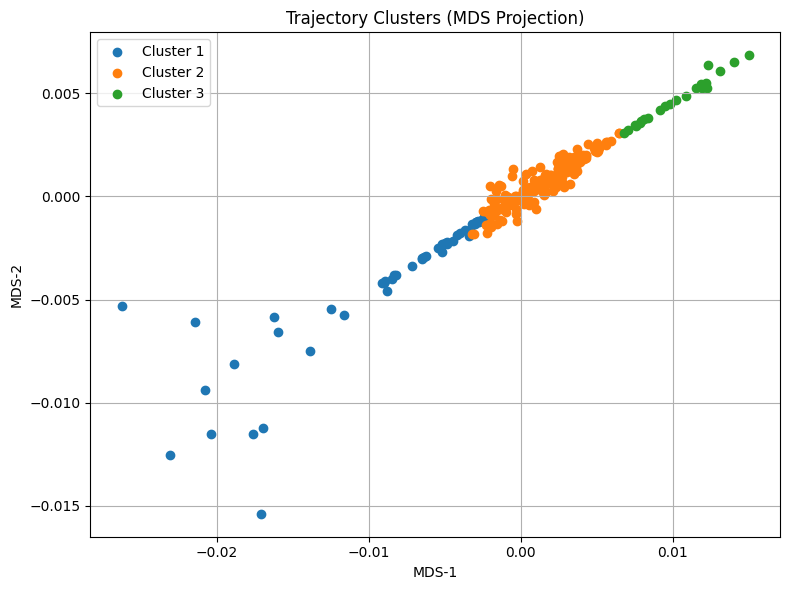

In [10]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import MDS


n_clusters = 3
clusters_real = AgglomerativeClustering(
    affinity='precomputed',
    linkage='complete',
    n_clusters=n_clusters
).fit(dist_matrix)

labels = clusters_real.labels_


mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
embedding = mds.fit_transform(dist_matrix)


plt.figure(figsize=(8, 6))
for cluster_id in range(n_clusters):
    idx = labels == cluster_id
    plt.scatter(embedding[idx, 0], embedding[idx, 1], label=f"Cluster {cluster_id+1}")

plt.title("Trajectory Clusters (MDS Projection)")
plt.xlabel("MDS-1")
plt.ylabel("MDS-2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
def rank_cluster_labels(labels):

    counts = Counter(labels)
    sorted_labels = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    label_map = {old: new for new, (old, _) in enumerate(sorted_labels)}
    return np.array([label_map[l] for l in labels])

def map_labels_to_subpaths(mmd_blocks, subpaths, group_labels, get_memberships_fn):

    memberships = get_memberships_fn(mmd_blocks)
    avg_scores = np.array([np.mean(group_labels[m]) for m in memberships])
    return avg_scores

def plot_colored_subpaths_with_cluster_bands(subpaths, cluster_scores, width=8, label_name="BIT-USD"):

    unique_scores = np.unique(cluster_scores)
    cmap = sns.diverging_palette(133, 20, l=60, n=len(unique_scores), center="light")

    plt.figure(figsize=(width, width * 0.618))
    ax = plt.gca()

    for i, path in enumerate(subpaths):
        timestamps = pd.to_datetime(path[:, 0].astype(int), unit="s")
        price_series = path[:, -1]
        cluster_val = cluster_scores[i]
        color_idx = int(np.argwhere(cluster_val == unique_scores)[0][0])
        color = cmap[color_idx]

       
        ax.plot(timestamps, price_series, color=color, alpha=0.8, label=label_name)

        
        ax.axvspan(timestamps[0], timestamps[-1], color=color, alpha=0.12)

    ax.set_title("Colored Subpaths by Cluster Score")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.grid(True)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper left", prop={'size': 10})

    return ax

def visualize_clustered_paths(mmd_real, sp_real, cluster_labels, get_memberships_fn, width=10):

    ranked_labels = rank_cluster_labels(cluster_labels)
    avg_scores = map_labels_to_subpaths(mmd_real, sp_real, ranked_labels, get_memberships_fn)

    ax = plot_colored_subpaths_with_cluster_bands(sp_real, avg_scores, width)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


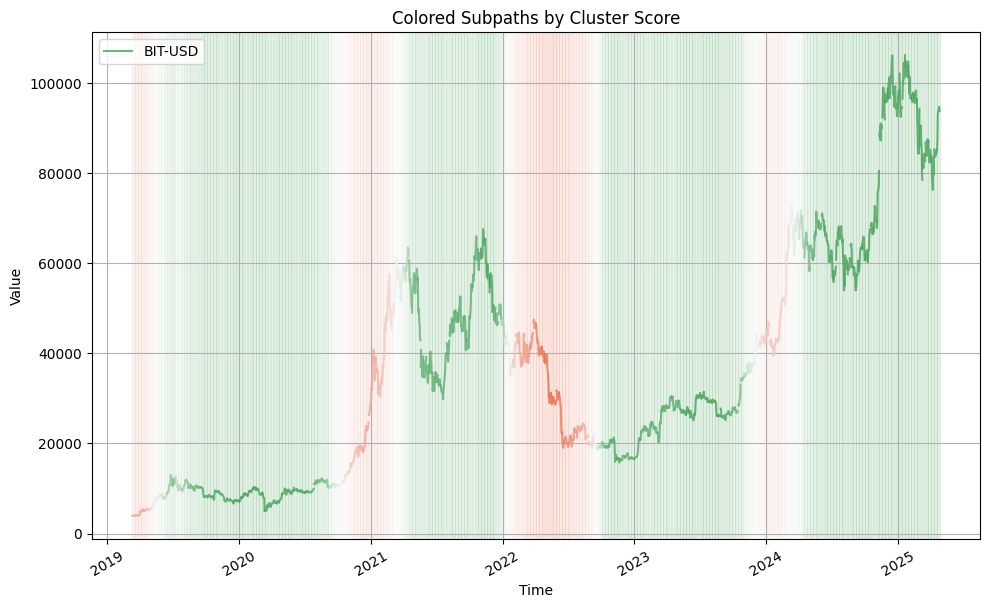

In [12]:
from collections import Counter

visualize_clustered_paths(
    mmd_real=grouped_paths,
    sp_real=sub_paths,
    cluster_labels=clusters_real.labels_,
    get_memberships_fn=get_memberships  # 你原有的函数
    
)

In [13]:
import pandas as pd

def get_subpath_cluster_dataframe(subpaths, mmd_blocks, group_labels, get_memberships_fn):
    memberships = get_memberships_fn(mmd_blocks)
    ranked_labels = rank_cluster_labels(group_labels)

    majority_clusters = np.array([
        Counter(ranked_labels[m]).most_common(1)[0][0] for m in memberships
    ])

    average_clusters = np.array([
        np.mean([ranked_labels[l] for l in m]) for m in memberships
    ])

    records = []
    for i, path in enumerate(subpaths):
        timestamps = pd.to_datetime(path[:, 0].astype(int), unit="s")
        prices = path[:, -1]
        cluster = majority_clusters[i]
        cluster_score = average_clusters[i]

        records.append({
            "subpath_index": i,
            "start_time": timestamps[0],
            "end_time": timestamps[-1],
            "mean_price": np.mean(prices),
            "cluster": cluster,
            "cluster_score": cluster_score
        })
    

    return pd.DataFrame(records)


df_clusters = get_subpath_cluster_dataframe(
    subpaths=sub_paths,
    mmd_blocks=grouped_paths,
    group_labels=clusters_real.labels_,
    get_memberships_fn=get_memberships
)

print(df_clusters.head())


   subpath_index start_time   end_time   mean_price  cluster  cluster_score
0              0 2019-03-11 2019-03-18  3964.105408        1            1.0
1              1 2019-03-19 2019-03-26  4027.263458        1            1.0
2              2 2019-03-27 2019-04-03  4309.711914        1            1.0
3              3 2019-04-04 2019-04-11  5137.745422        1            1.0
4              4 2019-04-12 2019-04-19  5188.831482        1            1.0


In [14]:
df_clusters.head(100)

,subpath_index,start_time,end_time,mean_price,cluster,cluster_score
0,0,2019-03-11,2019-03-18,3964.105408,1,1.00
1,1,2019-03-19,2019-03-26,4027.263458,1,1.00
2,2,2019-03-27,2019-04-03,4309.711914,1,1.00
3,3,2019-04-04,2019-04-11,5137.745422,1,1.00
4,4,2019-04-12,2019-04-19,5188.831482,1,1.00
...,...,...,...,...,...,...
95,95,2021-04-09,2021-04-16,61204.576172,0,0.40
96,96,2021-04-17,2021-04-24,54488.772949,0,0.35
97,97,2021-04-25,2021-05-02,54831.030273,0,0.30
98,98,2021-05-03,2021-05-10,56825.831055,0,0.25


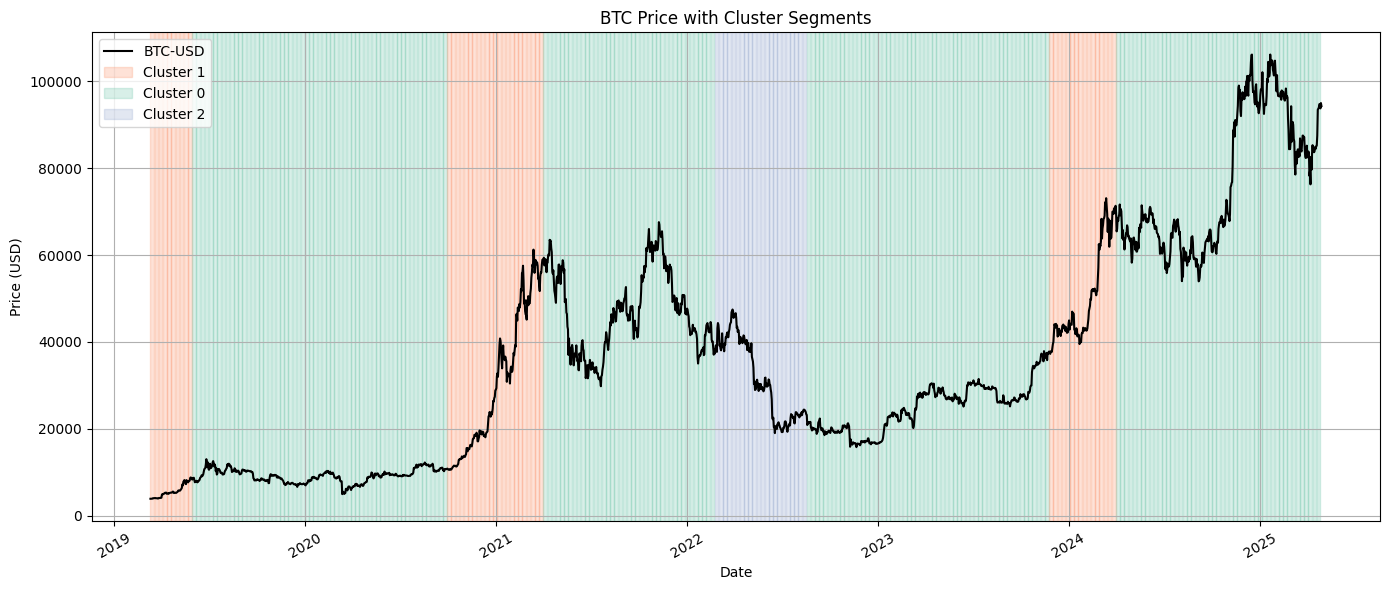

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

def plot_price_with_cluster_background(price_series, df_clusters, title="BTC Price with Cluster Segments"):

    fig, ax = plt.subplots(figsize=(14, 6))

   
    ax.plot(price_series.index, price_series.values, color="black", lw=1.5, label="BTC-USD")

    
    unique_clusters = sorted(df_clusters["cluster"].unique())
    cmap = sns.color_palette("Set2", n_colors=len(unique_clusters))
    cluster_to_color = {cl: cmap[i] for i, cl in enumerate(unique_clusters)}

    for _, row in df_clusters.iterrows():
        ax.axvspan(
            row["start_time"],
            row["end_time"],
            color=cluster_to_color[row["cluster"]],
            alpha=0.25,
            label=f"Cluster {int(row['cluster'])}"
        )

    
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper left")

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.grid(True)

    
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

plot_price_with_cluster_background(
    price_series = data_clean["Close"],
    df_clusters = df_clusters
)


In [16]:
import pandas as pd

# 初始化一个空的DataFrame
regime_signal = pd.DataFrame(index=pd.date_range(
    start=df_clusters["start_time"].min(),
    end=df_clusters["end_time"].max(),
    freq='D'
))

# 为每个时间段分配 cluster 标签
for _, row in df_clusters.iterrows():
    regime_signal.loc[row["start_time"]:row["end_time"], "cluster"] = row["cluster"]

# 如果有缺失值，用 forward fill 或填-1 表示未知状态
regime_signal["cluster"].fillna(method="ffill", inplace=True)

# 保存到CSV文件中
regime_signal.to_csv("btc_regime_signal.csv")

# 可视化查看某段信号



            cluster
2019-03-11      1.0
2019-03-12      1.0
2019-03-13      1.0
2019-03-14      1.0
2019-03-15      1.0
2019-03-16      1.0
2019-03-17      1.0
2019-03-18      1.0
2019-03-19      1.0
2019-03-20      1.0


In [17]:
print(regime_signal.head(50))

            cluster
2019-03-11      1.0
2019-03-12      1.0
2019-03-13      1.0
2019-03-14      1.0
2019-03-15      1.0
2019-03-16      1.0
2019-03-17      1.0
2019-03-18      1.0
2019-03-19      1.0
2019-03-20      1.0
2019-03-21      1.0
2019-03-22      1.0
2019-03-23      1.0
2019-03-24      1.0
2019-03-25      1.0
2019-03-26      1.0
2019-03-27      1.0
2019-03-28      1.0
2019-03-29      1.0
2019-03-30      1.0
2019-03-31      1.0
2019-04-01      1.0
2019-04-02      1.0
2019-04-03      1.0
2019-04-04      1.0
2019-04-05      1.0
2019-04-06      1.0
2019-04-07      1.0
2019-04-08      1.0
2019-04-09      1.0
2019-04-10      1.0
2019-04-11      1.0
2019-04-12      1.0
2019-04-13      1.0
2019-04-14      1.0
2019-04-15      1.0
2019-04-16      1.0
2019-04-17      1.0
2019-04-18      1.0
2019-04-19      1.0
2019-04-20      1.0
2019-04-21      1.0
2019-04-22      1.0
2019-04-23      1.0
2019-04-24      1.0
2019-04-25      1.0
2019-04-26      1.0
2019-04-27      1.0
2019-04-28      1.0


In [18]:
clusters_real.labels_

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [19]:
def rank_unique_elements(lst):
    
    counts = Counter(lst)

    # Sort the unique elements based on their counts in descending order
    ranked_elements = sorted(counts.items(), key=lambda x: x[1], reverse=True)

    # Extract the unique elements from the ranked list
    unique_elements = [item[0] for item in ranked_elements]

    return unique_elements

ranks = rank_unique_elements(clusters_real.labels_)
rank_dict = {r: i for i, r in enumerate(ranks)}
labels_real = [rank_dict[l] for l in clusters_real.labels_]

In [20]:
len(labels_real)

261

In [21]:
def run_cluster_momentum_strategy(
    df_clusters, 
    price_series, 
    cluster_long=[0], 
    score_weighting=True
):
    df = df_clusters.copy()

    # 使用滞后信号（避免未来信息）
    df["signal"] = df["cluster"].shift(1).apply(lambda c: 1 if c in cluster_long else 0)

    # 权重处理
    if score_weighting:
        score_min = df["cluster_score"].min()
        score_max = df["cluster_score"].max()
        df["weight"] = ((df["cluster_score"] - score_min) / (score_max - score_min)).clip(0, 1)
    else:
        df["weight"] = 1.0

    # 计算每个 subpath 区间的策略收益
    returns = []
    for _, row in df.iterrows():
        start = pd.to_datetime(row["start_time"])
        end = pd.to_datetime(row["end_time"])

        segment = price_series.loc[start:end]
        if len(segment) < 2:
            returns.append(0)
            continue

        pct_change = (segment.iloc[-1] - segment.iloc[0]) / segment.iloc[0]
        strat_return = pct_change * row["signal"] * row["weight"]
        returns.append(strat_return)

    df["strategy_return"] = returns
    df["cum_return"] = (1 + df["strategy_return"]).cumprod()

    # 添加动作列（买入 / 卖出）
    df["signal_shifted"] = df["signal"].shift(1)
    df["action"] = "HOLD"
    df.loc[(df["signal_shifted"] == 0) & (df["signal"] == 1), "action"] = "BUY"
    df.loc[(df["signal_shifted"] == 1) & (df["signal"] == 0), "action"] = "SELL"

    return df


In [22]:
import matplotlib.pyplot as plt

def plot_strategy(bt_df):
    plt.figure(figsize=(12, 4))
    plt.plot(bt_df["end_time"], bt_df["cum_return"], label="Strategy", color="blue")

    # 标记买入点
    plt.scatter(
        bt_df.loc[bt_df["action"] == "BUY", "end_time"],
        bt_df.loc[bt_df["action"] == "BUY", "cum_return"],
        marker="^", color="green", label="BUY", zorder=5
    )

    # 标记卖出点
    plt.scatter(
        bt_df.loc[bt_df["action"] == "SELL", "end_time"],
        bt_df.loc[bt_df["action"] == "SELL", "cum_return"],
        marker="v", color="red", label="SELL", zorder=5
    )

    plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
    plt.grid()
    plt.legend()
    plt.title("Cluster-Based Momentum Strategy with Buy/Sell Signals")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_combined_figure(bt_df, df_clusters, price_series, score_col="cluster_score", block_labels=None, n_paths=None):

    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    
    cmap = plt.get_cmap("coolwarm")
    norm = mcolors.Normalize(
        vmin=df_clusters[score_col].min(), 
        vmax=df_clusters[score_col].max()
    )

    segments = []
    for _, row in df_clusters.iterrows():
        start_time = pd.to_datetime(row["start_time"])
        end_time = pd.to_datetime(row["end_time"])
        segment = price_series.loc[start_time:end_time]
        if len(segment) < 2:
            continue

        x = mdates.date2num(segment.index.to_pydatetime())
        y = segment.values
        points = np.column_stack([x, y])
        segs = np.array([points[i:i+2] for i in range(len(points)-1)])
        segments.extend([(seg, row[score_col]) for seg in segs])

    if segments:
        lines, scores = zip(*segments)
        lc = LineCollection(lines, cmap=cmap, norm=norm, array=np.array(scores), linewidth=2, alpha=0.9)
        ax1.add_collection(lc)
        ax1.autoscale()
        ax1.set_ylabel("Price (USD)")
        ax1.set_title("BTC Price Colored by Cluster Score")
        ax1.grid(True)

        cax = inset_axes(ax1, width="2.5%", height="80%", loc='center left',
                 bbox_to_anchor=(1.01, 0.05, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)

        cbar = plt.colorbar(lc, cax=cax)
        cbar.set_label("Cluster Score")

    
    if block_labels is not None and n_paths is not None:
        aligned_start = n_paths - 1
        block_time_index = df_clusters["end_time"].iloc[aligned_start:].reset_index(drop=True)
        if len(block_labels) == len(block_time_index):
            ax1b = ax1.twinx()
            ax1b.plot(
                block_time_index,
                block_labels,
                linestyle="dotted",
                color="gray",
                linewidth=1.2,
                alpha=0.6,
                label="Block Cluster"
            )
            ax1b.set_ylabel("Block Cluster Label")
            ax1b.legend(loc="upper right", prop={'size': 9})

    
    ax2.plot(bt_df["end_time"], bt_df["cum_return"], label="Strategy", color="blue")

    
    ax2.scatter(
        bt_df.loc[bt_df["action"] == "BUY", "end_time"],
        bt_df.loc[bt_df["action"] == "BUY", "cum_return"],
        marker="^", color="green", label="BUY", zorder=5
    )
    ax2.scatter(
        bt_df.loc[bt_df["action"] == "SELL", "end_time"],
        bt_df.loc[bt_df["action"] == "SELL", "cum_return"],
        marker="v", color="red", label="SELL", zorder=5
    )

    ax2.axhline(1, color='gray', linestyle='--', alpha=0.5)
    ax2.set_ylabel("Cumulative Return")
    ax2.set_xlabel("Date")
    ax2.set_title("Cluster-Based Momentum Strategy")
    ax2.legend(loc="upper left")
    ax2.grid(True)

    
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax2.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax2.xaxis.get_major_locator()))
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


In [166]:
bt_df

,subpath_index,start_time,end_time,mean_price,cluster,cluster_score,signal,weight,strategy_return,cum_return,signal_shifted,action
0,0,2019-03-11,2019-03-18,3964.105408,1,1.0,0,0.5,Ticker BTC-USD 0.0 dtype: float64,Ticker BTC-USD 1.0 dtype: float64,NaN,HOLD
1,1,2019-03-19,2019-03-26,4027.263458,1,1.0,0,0.5,Ticker BTC-USD -0.0 dtype: float64,Ticker BTC-USD 1.0 dtype: float64,0.0,HOLD
2,2,2019-03-27,2019-04-03,4309.711914,1,1.0,0,0.5,Ticker BTC-USD 0.0 dtype: float64,Ticker BTC-USD 1.0 dtype: float64,0.0,HOLD
3,3,2019-04-04,2019-04-11,5137.745422,1,1.0,0,0.5,Ticker BTC-USD 0.0 dtype: float64,Ticker BTC-USD 1.0 dtype: float64,0.0,HOLD
4,4,2019-04-12,2019-04-19,5188.831482,1,1.0,0,0.5,Ticker BTC-USD 0.0 dtype: float64,Ticker BTC-USD 1.0 dtype: float64,0.0,HOLD
...,...,...,...,...,...,...,...,...,...,...,...,...
275,275,2025-03-19,2025-03-26,85852.877930,0,0.0,1,0.0,Ticker BTC-USD 0.0 dtype: float64,Ticker BTC-USD 1.174702 dtype: float64,1.0,HOLD
276,276,2025-03-27,2025-04-03,83721.123047,0,0.0,1,0.0,Ticker BTC-USD -0.0 dtype: float64,Ticker BTC-USD 1.174702 dtype: float64,1.0,HOLD
277,277,2025-04-04,2025-04-11,80834.413086,0,0.0,1,0.0,Ticker BTC-USD -0.0 dtype: float64,Ticker BTC-USD 1.174702 dtype: float64,1.0,HOLD
278,278,2025-04-12,2025-04-19,84453.413086,0,0.0,1,0.0,Ticker BTC-USD -0.0 dtype: float64,Ticker BTC-USD 1.174702 dtype: float64,1.0,HOLD


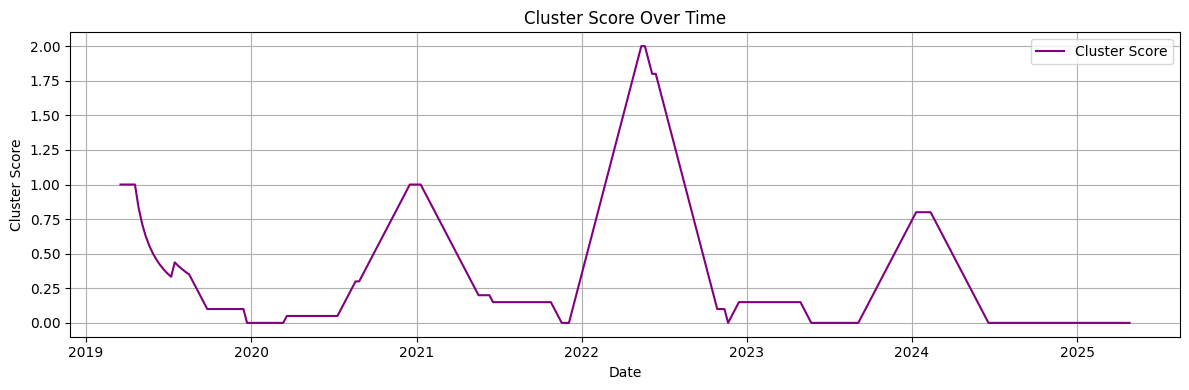

In [188]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(bt_df["end_time"], bt_df["cluster_score"], color="purple", label="Cluster Score")
plt.title("Cluster Score Over Time")
plt.xlabel("Date")
plt.ylabel("Cluster Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


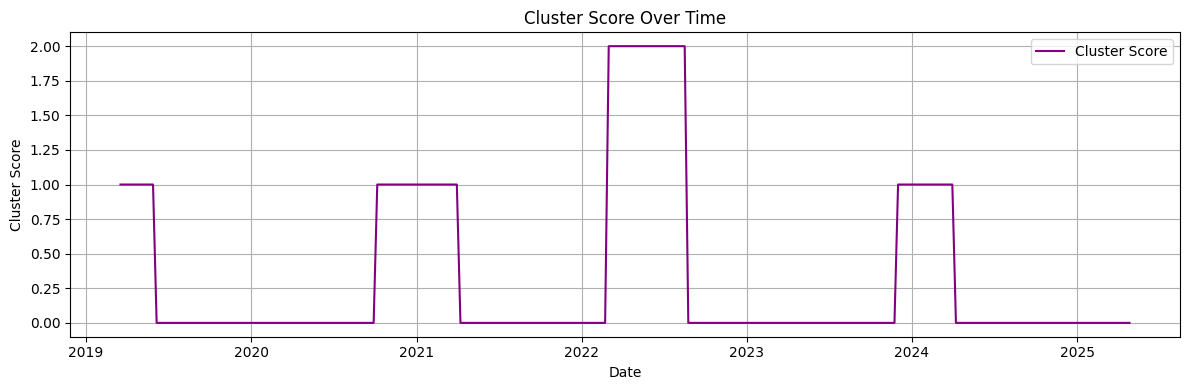

In [189]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(bt_df["end_time"], bt_df["cluster"], color="purple", label="Cluster Score")
plt.title("Cluster Score Over Time")
plt.xlabel("Date")
plt.ylabel("Cluster Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def run_cluster_momentum_strategy(
    df_clusters, 
    price_series, 
    cluster_long=[1], 
    score_weighting=True
):
    df = df_clusters.copy()

    
    df["signal"] = df["cluster"].shift(1).apply(lambda c: 1 if c in cluster_long else 0)

    
    if score_weighting:
        score_min = df["cluster_score"].min()
        score_max = df["cluster_score"].max()
        df["weight"] = ((df["cluster_score"] - score_min) / (score_max - score_min)).clip(0, 1)
    else:
        df["weight"] = 1.0

    
    returns = []
    for _, row in df.iterrows():
        start = pd.to_datetime(row["start_time"])
        end = pd.to_datetime(row["end_time"])

        segment = price_series.loc[start:end]
        if len(segment) < 2:
            returns.append(0)
            continue

        pct_change = (segment.iloc[-1] - segment.iloc[0]) / segment.iloc[0]
        strat_return = pct_change * row["signal"] * row["weight"]
        returns.append(strat_return)

    df["strategy_return"] = returns
    df["cum_return"] = (1 + df["strategy_return"]).cumprod()

    
    df["signal_shifted"] = df["signal"].shift(1)
    df["action"] = "HOLD"
    df.loc[(df["signal_shifted"] == 0) & (df["signal"] == 1), "action"] = "BUY"
    df.loc[(df["signal_shifted"] == 1) & (df["signal"] == 0), "action"] = "SELL"

    return df


/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_46189/3914321071.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


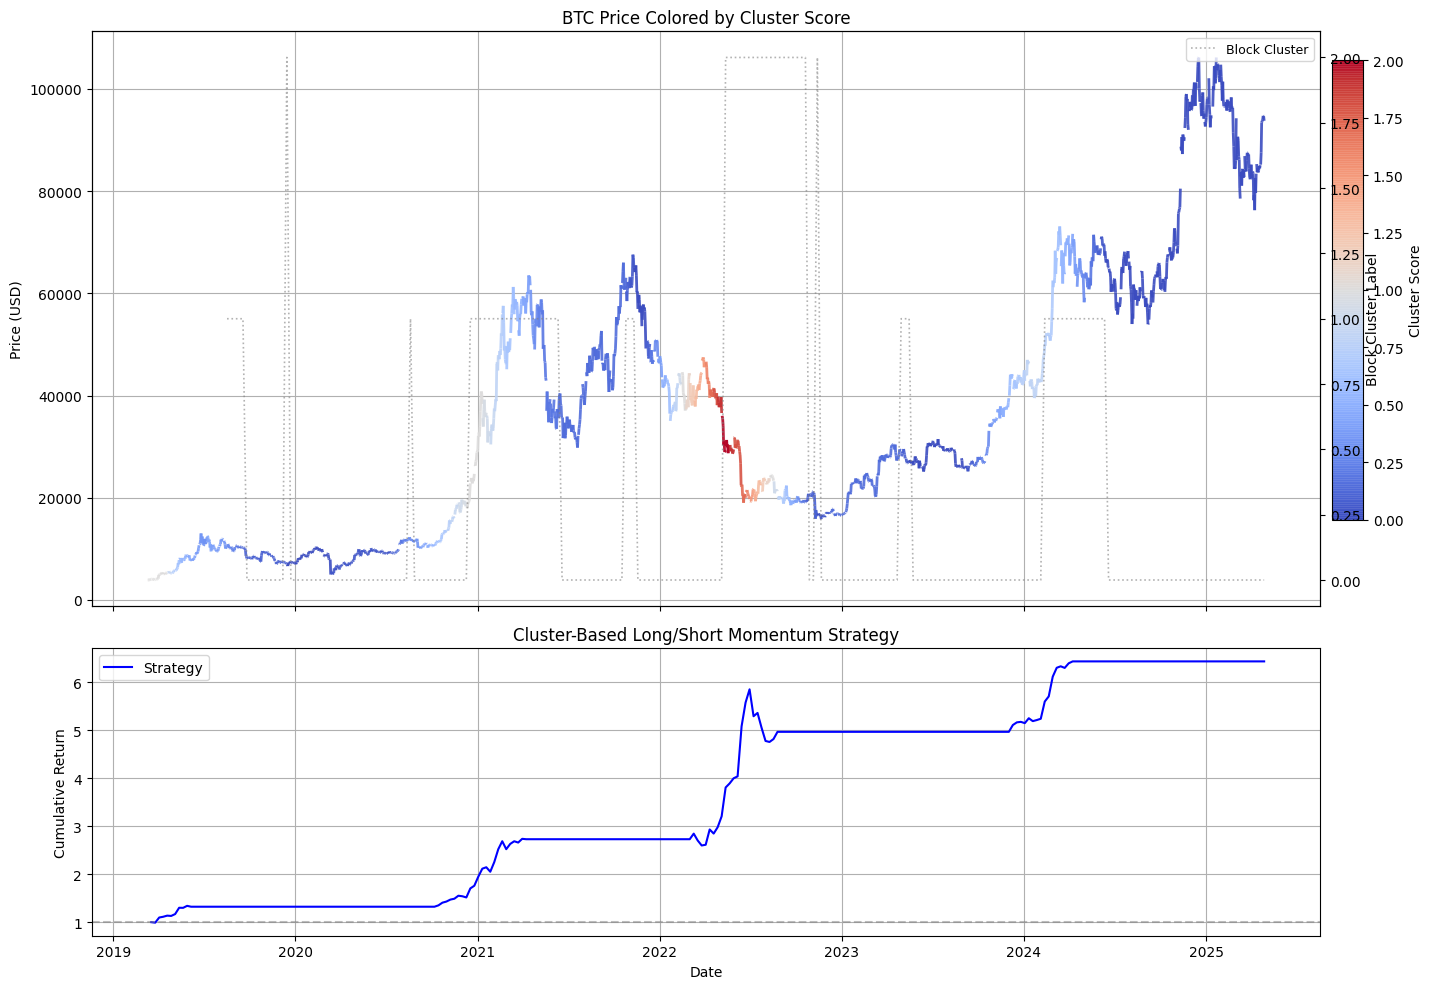


📊 Per-Cluster Sharpe Ratio:
Cluster 0: Sharpe = 0.042 (mean=0.0001, std=0.0024)
Cluster 1: Sharpe = 0.654 (mean=0.0271, std=0.0415)
Cluster 2: Sharpe = 0.355 (mean=0.0292, std=0.0822)


In [196]:
bt_df = run_cluster_momentum_strategy(
    df_clusters=df_clusters,
    price_series=data_clean["Close"],
    cluster_long=[1],        
    score_weighting=True     
)

plot_combined_figure(
    bt_df=bt_df,
    df_clusters=df_clusters,
    price_series=data_clean["Close"],
    block_labels=labels_real,
    n_paths=20
)


In [197]:
def run_cluster_momentum_strategy(df_clusters, price_series, score_weighting=True):
    df = df_clusters.copy()

    
    df["signal"] = df["cluster"].shift(1).map({1: 1, 2: -1}).fillna(0)

    
    if score_weighting:
        score_min = df["cluster_score"].min()
        score_max = df["cluster_score"].max()
        score_norm = ((df["cluster_score"] - score_min) / (score_max - score_min)).clip(0, 1)

        df["weight"] = 0.0
        df.loc[df["signal"] == 1, "weight"]  = score_norm[df["signal"] == 1]         # 多头仓位
        df.loc[df["signal"] == -1, "weight"] = 1 - score_norm[df["signal"] == -1]    # 空头仓位
    else:
        df["weight"] = 1.0

    
    returns = []
    for _, row in df.iterrows():
        start = pd.to_datetime(row["start_time"])
        end   = pd.to_datetime(row["end_time"])
        segment = price_series.loc[start:end]
        if len(segment) < 2:
            returns.append(0)
            continue
        pct_change = (segment.iloc[-1] - segment.iloc[0]) / segment.iloc[0]
        strat_return = pct_change * row["signal"] * row["weight"]
        returns.append(strat_return)

    df["strategy_return"] = returns
    df["cum_return"] = (1 + df["strategy_return"]).cumprod()

    
    df["signal_shifted"] = df["signal"].shift(1)
    df["action"] = "HOLD"
    df.loc[(df["signal_shifted"] == 0) & (df["signal"] == 1), "action"] = "LONG_ENTRY"
    df.loc[(df["signal_shifted"] == 1) & (df["signal"] == 0), "action"] = "LONG_EXIT"
    df.loc[(df["signal_shifted"] == 0) & (df["signal"] == -1), "action"] = "SHORT_ENTRY"
    df.loc[(df["signal_shifted"] == -1) & (df["signal"] == 0), "action"] = "SHORT_EXIT"
    df.loc[(df["signal_shifted"] == 1) & (df["signal"] == -1), "action"] = "LONG_TO_SHORT"
    df.loc[(df["signal_shifted"] == -1) & (df["signal"] == 1), "action"] = "SHORT_TO_LONG"

    return df


In [209]:
from matplotlib.collections import LineCollection

def run_cluster_momentum_strategy(df_clusters, price_series, score_weighting=True):
    df = df_clusters.copy()

    # Generate trading signal based on cluster (1 = long, 2 = short)
    df["signal"] = df["cluster"].shift(1).map({1: 1, 2: -1}).fillna(0)

    # Position sizing based on cluster confidence score
    if score_weighting:
        df["weight"] = 0.0

        # Long signal confidence (closer to 1 is better)
        long_conf = 1 - (df["cluster_score"] - 1).abs()
        long_conf_norm = (long_conf - long_conf.min()) / (long_conf.max() - long_conf.min())
        df.loc[df["signal"] == 1, "weight"] = long_conf_norm[df["signal"] == 1]

        # Short signal confidence (closer to 2 is better)
        short_conf = 1 - (df["cluster_score"] - 2).abs()
        short_conf_norm = (short_conf - short_conf.min()) / (short_conf.max() - short_conf.min())
        df.loc[df["signal"] == -1, "weight"] = short_conf_norm[df["signal"] == -1]
    else:
        df["weight"] = 1.0

    # Strategy return calculation
    returns = []
    for _, row in df.iterrows():
        start = pd.to_datetime(row["start_time"])
        end   = pd.to_datetime(row["end_time"])
        segment = price_series.loc[start:end]
        if len(segment) < 2:
            returns.append(0)
            continue
        pct_change = (segment.iloc[-1] - segment.iloc[0]) / segment.iloc[0]
        strat_return = pct_change * row["signal"] * row["weight"]
        returns.append(strat_return)

    df["strategy_return"] = returns
    df["cum_return"] = (1 + df["strategy_return"]).cumprod()

    # Trade action tagging
    df["signal_shifted"] = df["signal"].shift(1)
    df["action"] = "HOLD"
    df.loc[(df["signal_shifted"] == 0) & (df["signal"] == 1), "action"] = "LONG_ENTRY"
    df.loc[(df["signal_shifted"] == 1) & (df["signal"] == 0), "action"] = "LONG_EXIT"
    df.loc[(df["signal_shifted"] == 0) & (df["signal"] == -1), "action"] = "SHORT_ENTRY"
    df.loc[(df["signal_shifted"] == -1) & (df["signal"] == 0), "action"] = "SHORT_EXIT"
    df.loc[(df["signal_shifted"] == 1) & (df["signal"] == -1), "action"] = "LONG_TO_SHORT"
    df.loc[(df["signal_shifted"] == -1) & (df["signal"] == 1), "action"] = "SHORT_TO_LONG"
    
    return df

def plot_combined_figure(bt_df, df_clusters, price_series, score_col="cluster_score", block_labels=None, n_paths=None):
    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1, figsize=(14, 10), sharex=True, 
        gridspec_kw={'height_ratios': [2, 1]}
    )

    # === Plot 1: Price with color gradient by cluster_score ===
    cmap = plt.get_cmap("coolwarm")
    norm = mcolors.Normalize(vmin=df_clusters[score_col].min(), vmax=df_clusters[score_col].max())

    segments = []
    for _, row in df_clusters.iterrows():
        start_time = pd.to_datetime(row["start_time"])
        end_time = pd.to_datetime(row["end_time"])
        segment = price_series.loc[start_time:end_time]
        if len(segment) < 2:
            continue
        x = mdates.date2num(segment.index.to_pydatetime())
        y = segment.values
        points = np.column_stack([x, y])
        segs = np.array([points[i:i+2] for i in range(len(points)-1)])
        segments.extend([(seg, row[score_col]) for seg in segs])

    if segments:
        lines, scores = zip(*segments)
        lc = LineCollection(lines, cmap=cmap, norm=norm, array=np.array(scores), linewidth=2, alpha=0.9)
        ax1.add_collection(lc)
        ax1.autoscale()
        ax1.set_ylabel("Price (USD)")
        ax1.set_title("BTC Price Colored by Cluster Score")
        ax1.grid(True)

        # Colorbar for cluster score
        cax = inset_axes(ax1, width="2.5%", height="80%", loc='center left',
                         bbox_to_anchor=(1.01, 0.05, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
        cbar = plt.colorbar(lc, cax=cax)
        cbar.set_label("Cluster Score")

    # === Optional: Block-level label overlay ===
    if block_labels is not None and n_paths is not None:
        aligned_start = n_paths - 1
        block_time_index = df_clusters["end_time"].iloc[aligned_start:].reset_index(drop=True)
        if len(block_labels) == len(block_time_index):
            ax1b = ax1.twinx()
            ax1b.plot(
                block_time_index,
                block_labels,
                linestyle="dotted",
                color="gray",
                linewidth=1.2,
                alpha=0.6,
                label="Block Cluster"
            )
            ax1b.set_ylabel("Block Cluster Label")
            ax1b.legend(loc="upper right", prop={'size': 9})

    # === Plot 2: Strategy cumulative return ===
    ax2.plot(bt_df["end_time"], bt_df["cum_return"], label="Strategy", color="blue")

    # === Mark trading signals ===
    action_styles = {
        "LONG_ENTRY":     {"marker": "^", "color": "green",    "label": "Long Entry"},
        "LONG_EXIT":      {"marker": "v", "color": "darkgreen","label": "Long Exit"},
        "SHORT_ENTRY":    {"marker": "v", "color": "red",      "label": "Short Entry"},
        "SHORT_EXIT":     {"marker": "^", "color": "darkred",  "label": "Short Exit"},
        "LONG_TO_SHORT":  {"marker": "o", "color": "purple",   "label": "Long→Short"},
        "SHORT_TO_LONG":  {"marker": "o", "color": "orange",   "label": "Short→Long"},
    }

    handled_labels = set()
    for action, style in action_styles.items():
        subset = bt_df.loc[bt_df["action"] == action]
        if not subset.empty:
            label = style["label"] if style["label"] not in handled_labels else None
            ax2.scatter(
                subset["end_time"],
                subset["cum_return"],
                marker=style["marker"],
                color=style["color"],
                label=label,
                zorder=5
            )
            handled_labels.add(style["label"])

    ax2.axhline(1, color='gray', linestyle='--', alpha=0.5)
    ax2.set_ylabel("Cumulative Return")
    ax2.set_xlabel("Date")
    ax2.set_title("Cluster-Based Long/Short Momentum Strategy")
    ax2.legend(loc="upper left")
    ax2.grid(True)

    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax2.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax2.xaxis.get_major_locator()))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    # Print Sharpe Ratio by cluster
    print("\n Per-Cluster Sharpe Ratio:")
    cluster_returns = bt_df.groupby("cluster")["strategy_return"]
    for cl, ret in cluster_returns:
        mu = ret.mean()
        sigma = ret.std()
        sharpe = mu / sigma if sigma != 0 else 0
        print(f"Cluster {cl}: Sharpe = {sharpe:.3f} (mean={mu:.4f}, std={sigma:.4f})")


/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_46189/372101832.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


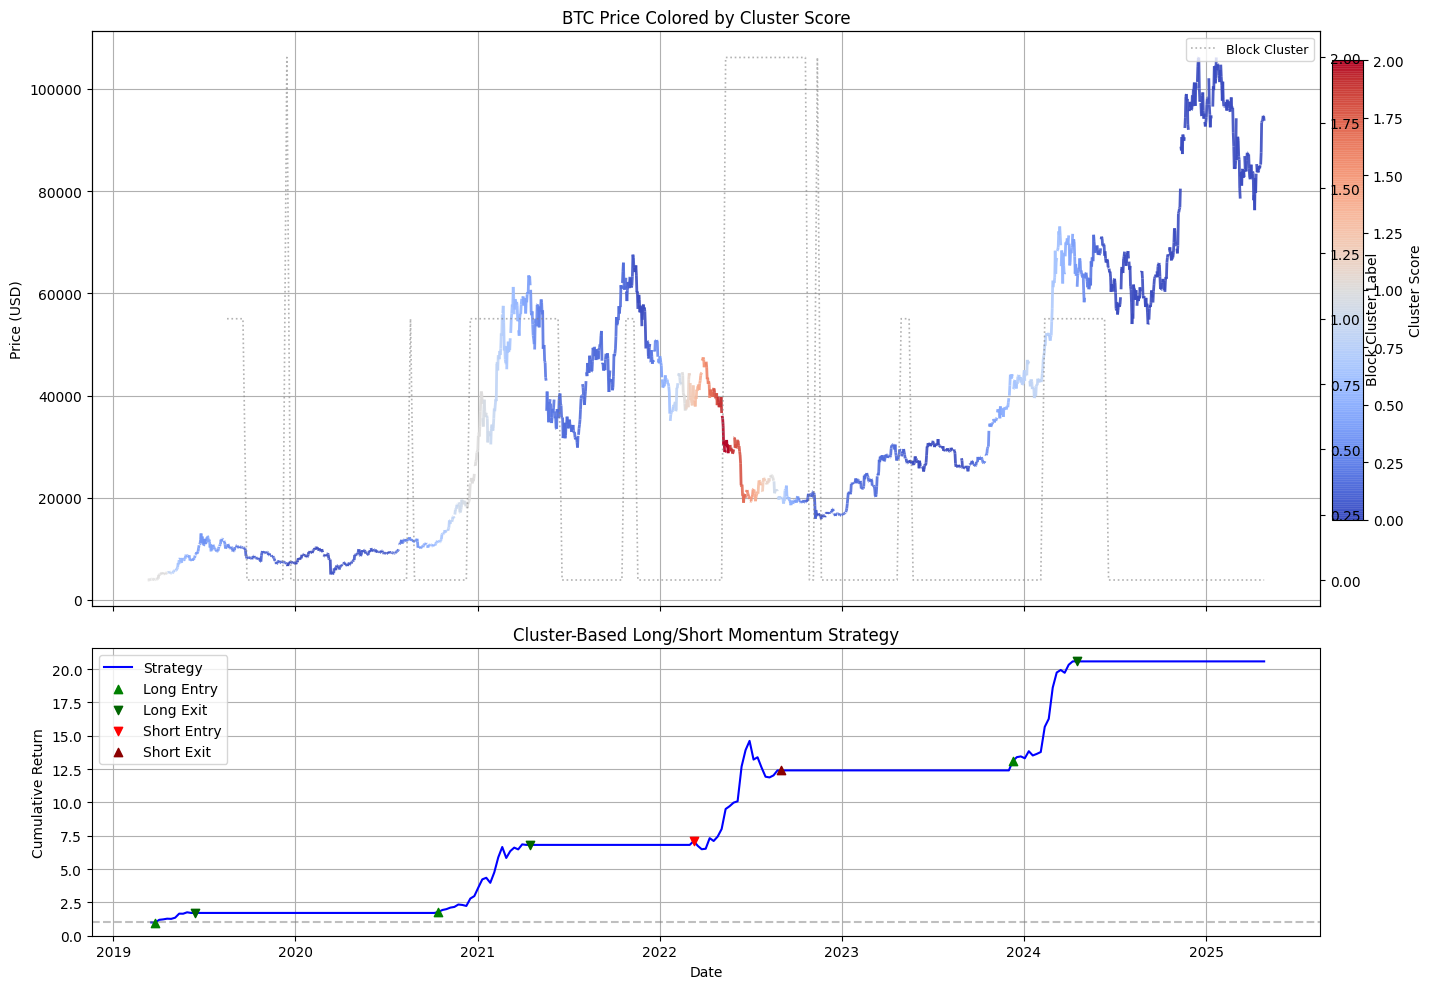


 Per-Cluster Sharpe Ratio:
Cluster 0: Sharpe = 0.017 (mean=0.0001, std=0.0030)
Cluster 1: Sharpe = 0.654 (mean=0.0543, std=0.0829)
Cluster 2: Sharpe = 0.355 (mean=0.0292, std=0.0822)


In [213]:

bt_df = run_cluster_momentum_strategy(
    df_clusters=df_clusters,
    price_series=data_clean["Close"],
    score_weighting=True 
)


plot_combined_figure(
    bt_df=bt_df,
    df_clusters=df_clusters,
    price_series=data_clean["Close"],
    block_labels=labels_real,  
    n_paths=n_paths             
)


/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_46189/372101832.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


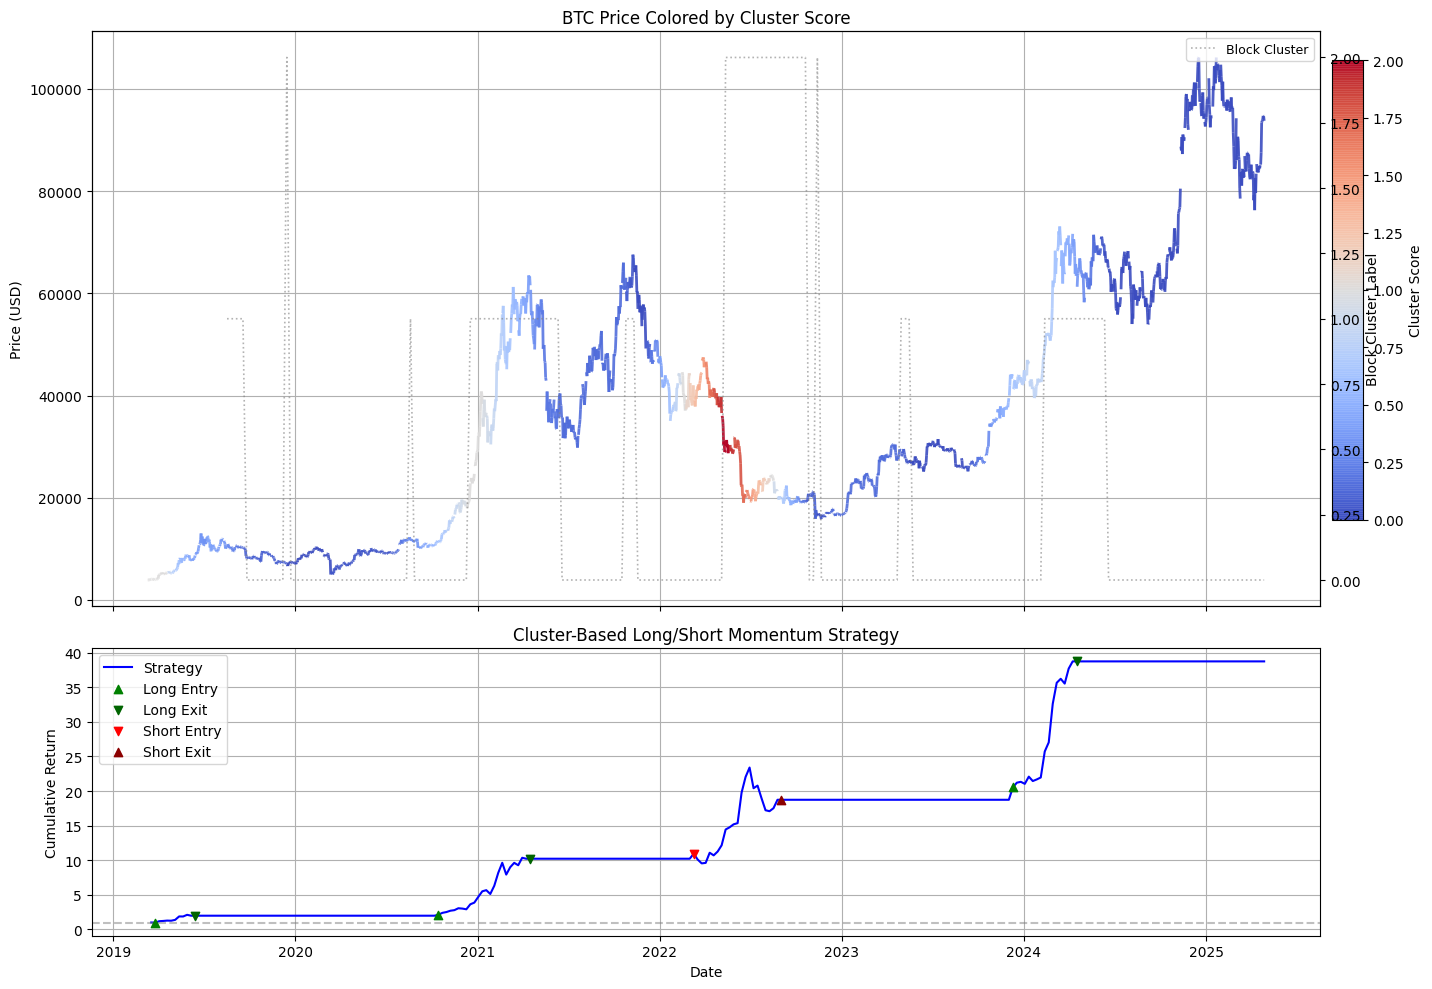


 Per-Cluster Sharpe Ratio:
Cluster 0: Sharpe = 0.017 (mean=0.0001, std=0.0067)
Cluster 1: Sharpe = 0.684 (mean=0.0699, std=0.1023)
Cluster 2: Sharpe = 0.299 (mean=0.0290, std=0.0972)


In [214]:
# 假设你已有 df_clusters 和 data_clean["Close"]

bt_df = run_cluster_momentum_strategy(
    df_clusters=df_clusters,
    price_series=data_clean["Close"],
    score_weighting=False  # 是否考虑 cluster_score 动态权重
)


plot_combined_figure(
    bt_df=bt_df,
    df_clusters=df_clusters,
    price_series=data_clean["Close"],
    block_labels=labels_real,  # 可选
    n_paths=n_paths             # 可选
)


In [215]:
bt_df

,subpath_index,start_time,end_time,mean_price,cluster,cluster_score,signal,weight,strategy_return,cum_return,signal_shifted,action
0,0,2019-03-11,2019-03-18,3964.105408,1,1.0,0.0,1.0,Ticker BTC-USD 0.0 dtype: float64,Ticker BTC-USD 1.0 dtype: float64,NaN,HOLD
1,1,2019-03-19,2019-03-26,4027.263458,1,1.0,1.0,1.0,Ticker BTC-USD -0.021151 dtype: float64,Ticker BTC-USD 0.978849 dtype: float64,0.0,LONG_ENTRY
2,2,2019-03-27,2019-04-03,4309.711914,1,1.0,1.0,1.0,Ticker BTC-USD 0.216771 dtype: float64,Ticker BTC-USD 1.191035 dtype: float64,1.0,HOLD
3,3,2019-04-04,2019-04-11,5137.745422,1,1.0,1.0,1.0,Ticker BTC-USD 0.028782 dtype: float64,Ticker BTC-USD 1.225315 dtype: float64,1.0,HOLD
4,4,2019-04-12,2019-04-19,5188.831482,1,1.0,1.0,1.0,Ticker BTC-USD 0.042101 dtype: float64,Ticker BTC-USD 1.276902 dtype: float64,1.0,HOLD
...,...,...,...,...,...,...,...,...,...,...,...,...
275,275,2025-03-19,2025-03-26,85852.877930,0,0.0,0.0,1.0,Ticker BTC-USD 0.0 dtype: float64,Ticker BTC-USD 38.739772 dtype: float64,0.0,HOLD
276,276,2025-03-27,2025-04-03,83721.123047,0,0.0,0.0,1.0,Ticker BTC-USD -0.0 dtype: float64,Ticker BTC-USD 38.739772 dtype: float64,0.0,HOLD
277,277,2025-04-04,2025-04-11,80834.413086,0,0.0,0.0,1.0,Ticker BTC-USD -0.0 dtype: float64,Ticker BTC-USD 38.739772 dtype: float64,0.0,HOLD
278,278,2025-04-12,2025-04-19,84453.413086,0,0.0,0.0,1.0,Ticker BTC-USD -0.0 dtype: float64,Ticker BTC-USD 38.739772 dtype: float64,0.0,HOLD
